<a href="https://colab.research.google.com/github/Chinmayykashyap-git/FinSight-Risk-Engine/blob/main/FinSight_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "fedesoriano/company-bankruptcy-prediction"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'company-bankruptcy-prediction' dataset.
Dataset Path: /kaggle/input/company-bankruptcy-prediction


In [4]:
import os

print(os.listdir(path))

['data.csv']


In [5]:
import pandas as pd

df = pd.read_csv(f"{path}/data.csv")

print("Shape:", df.shape)

df.head()

Shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [6]:
# Column information
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Target distribution
print("\nTarget Distribution:")
print(df["Bankrupt?"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

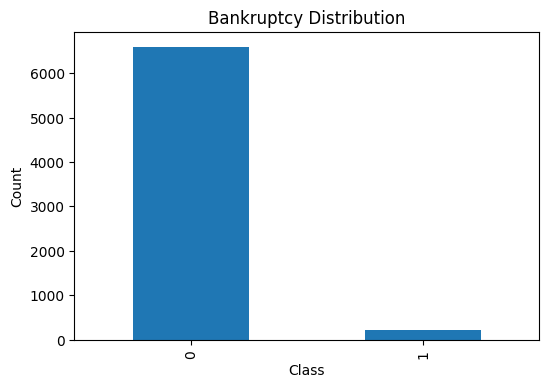

Bankrupt?
0    6599
1     220
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt

counts = df["Bankrupt?"].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Bankruptcy Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(counts)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


In [9]:
corr = df.corr(numeric_only=True)

target_corr = corr["Bankrupt?"].sort_values(
    ascending=False
)

print(target_corr.head(15))
print("\n")
print(target_corr.tail(15))

Bankrupt?                                       1.000000
 Debt ratio %                                   0.250161
 Current Liability to Assets                    0.194494
 Borrowing dependency                           0.176543
 Current Liability to Current Assets            0.171306
 Liability to Equity                            0.166812
 Current Liabilities/Equity                     0.153828
 Current Liability to Equity                    0.153828
 Liability-Assets Flag                          0.139212
 Total expense/Assets                           0.139049
 Equity to Long-term Liability                  0.139014
 Cash/Current Liability                         0.077921
 Inventory and accounts receivable/Net value    0.075278
 Fixed Assets Turnover Frequency                0.072818
 Contingent liabilities/Net worth               0.070455
Name: Bankrupt?, dtype: float64


Net Value Per Share (C)                                   -0.164784
Net Value Per Share (B)                    

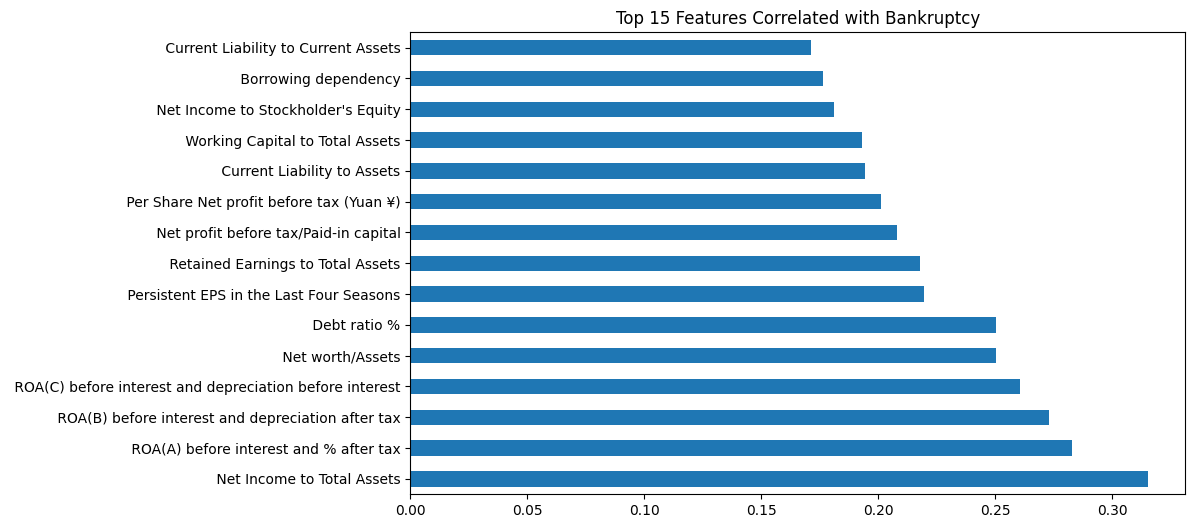

In [10]:
import matplotlib.pyplot as plt

top_features = target_corr.drop("Bankrupt?").abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind="barh")
plt.title("Top 15 Features Correlated with Bankruptcy")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5455, 95)
(1364, 95)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

preds = pipeline.predict(X_test)

print(classification_report(y_test, preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

probs = pipeline.predict_proba(X_test)[:,1]

print(
    "\nROC AUC:",
    roc_auc_score(y_test, probs)
)

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.19      0.82      0.30        44

    accuracy                           0.88      1364
   macro avg       0.59      0.85      0.62      1364
weighted avg       0.97      0.88      0.91      1364


Confusion Matrix:
[[1162  158]
 [   8   36]]

ROC AUC: 0.9171487603305785


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print(classification_report(
    y_test,
    rf_preds
))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.41      0.57      0.48        44

    accuracy                           0.96      1364
   macro avg       0.70      0.77      0.73      1364
weighted avg       0.97      0.96      0.96      1364



In [16]:
rf_probs = rf.predict_proba(X_test)[:,1]

print(
    "Random Forest ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_probs
    )
)

Random Forest ROC-AUC: 0.94409435261708


In [17]:
!pip install xgboost


In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

xgb_preds = xgb.predict(X_test)

print(classification_report(
    y_test,
    xgb_preds
))

xgb_probs = xgb.predict_proba(X_test)[:,1]

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_probs
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1320
           1       0.65      0.34      0.45        44

    accuracy                           0.97      1364
   macro avg       0.82      0.67      0.72      1364
weighted avg       0.97      0.97      0.97      1364

ROC-AUC: 0.9614152892561983


In [20]:
!pip install shap

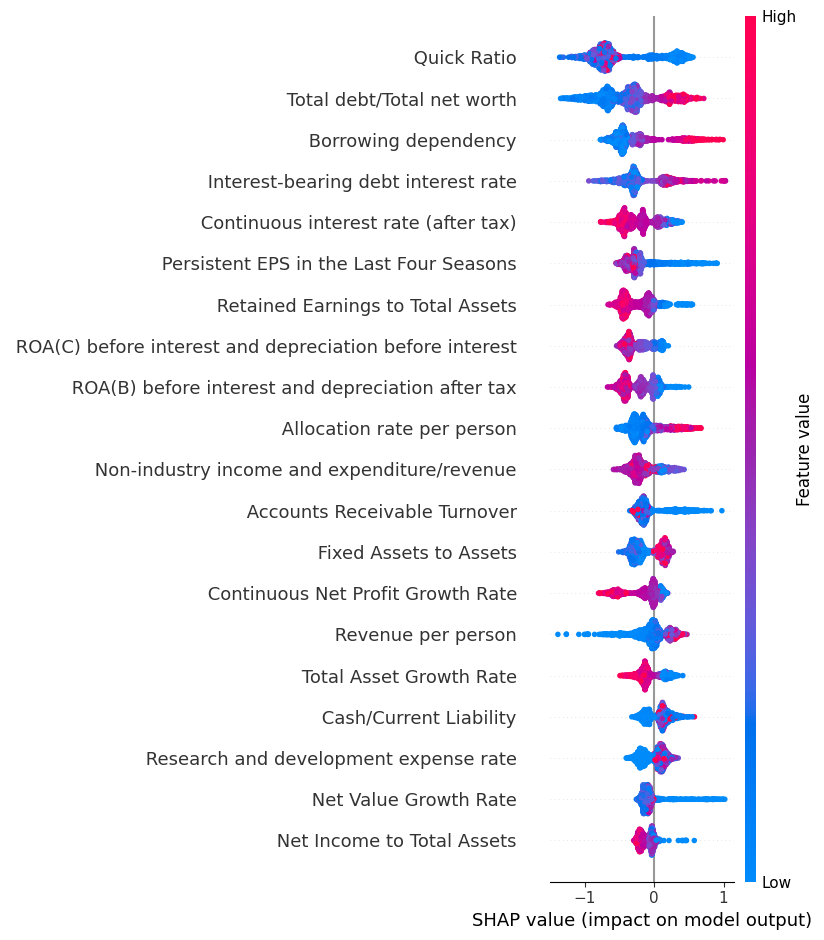

In [21]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

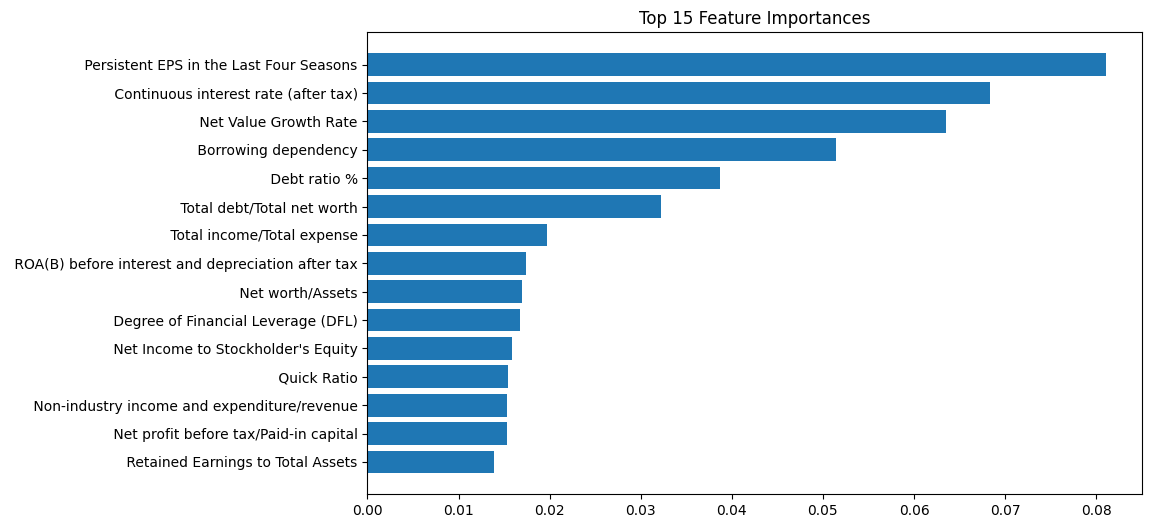

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    "max_depth":[4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "n_estimators":[200,300,500],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    params,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

search.fit(X_train,y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
0.9408558927255656


In [25]:
!pip install imbalanced-learn

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Bankrupt?
0    5279
1     176
Name: count, dtype: int64
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [28]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

preds_smote = rf_smote.predict(X_test)

print(
    classification_report(
        y_test,
        preds_smote
    )
)

probs_smote = rf_smote.predict_proba(X_test)[:,1]

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        probs_smote
    )
)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.33      0.77      0.46        44

    accuracy                           0.94      1364
   macro avg       0.66      0.86      0.71      1364
weighted avg       0.97      0.94      0.95      1364

ROC-AUC: 0.9496039944903581


In [29]:
comparison = {
    "Model": [
        "Random Forest",
        "Random Forest + SMOTE"
    ],
    "ROC_AUC": [
        0.944,
        roc_auc_score(
            y_test,
            probs_smote
        )
    ]
}

import pandas as pd

pd.DataFrame(comparison)

,Model,ROC_AUC
0,Random Forest,0.944000
1,Random Forest + SMOTE,0.949604


In [30]:
def risk_level(prob):

    if prob < 0.30:
        return "Low Risk"

    elif prob < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [31]:
sample = X_test.iloc[[0]]

prob = rf_smote.predict_proba(sample)[0][1]

print(
    "Bankruptcy Probability:",
    round(prob * 100, 2),
    "%"
)

print(
    "Risk Level:",
    risk_level(prob)
)

Bankruptcy Probability: 9.0 %
Risk Level: Low Risk


In [32]:
import shap

explainer = shap.TreeExplainer(
    rf_smote
)

sample = X_test.iloc[[0]]

shap_values = explainer.shap_values(
    sample
)

In [33]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [34]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1, 95, 2)


In [35]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (95, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [36]:
sample = X_test.iloc[[0]]

explanation = explainer(sample)

print(type(explanation))
print(explanation.values.shape)

<class 'shap._explanation.Explanation'>
(1, 95, 2)


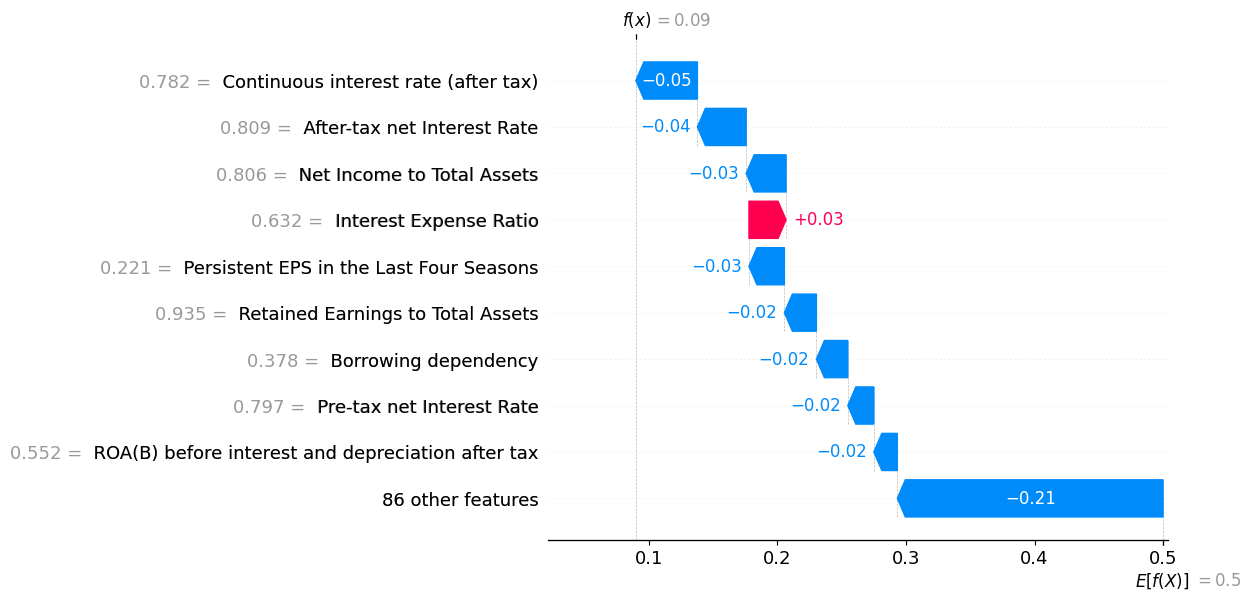

In [37]:
shap.plots.waterfall(
    shap.Explanation(
        values=explanation.values[0, :, 1],
        base_values=explanation.base_values[0, 1],
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

In [38]:
def predict_company_risk(company_data):

    probability = rf_smote.predict_proba(company_data)[0][1]

    if probability < 0.30:
        risk = "Low Risk"

    elif probability < 0.60:
        risk = "Medium Risk"

    else:
        risk = "High Risk"

    return {
        "Probability": round(probability * 100, 2),
        "Risk Level": risk
    }

In [39]:
sample_company = X_test.iloc[[0]]

result = predict_company_risk(sample_company)

print(result)

{'Probability': np.float64(9.0), 'Risk Level': 'Low Risk'}


In [40]:
test_probs = rf_smote.predict_proba(X_test)[:,1]

risk_df = X_test.copy()

risk_df["Actual"] = y_test.values
risk_df["Risk_Probability"] = test_probs

risk_df.sort_values(
    "Risk_Probability",
    ascending=False
).head(10)

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Actual,Risk_Probability
231,0.456345,0.503925,0.498528,0.594474,0.594474,0.998869,0.797120,0.809062,0.303262,0.781287,...,0.617529,0.594474,0.836782,0.286674,0.026287,0.560558,1,0.018304,1,0.976939
2640,0.325793,0.362680,0.359441,0.595231,0.595231,0.998749,0.796923,0.808865,0.303171,0.781088,...,0.623458,0.595232,0.637576,0.484318,0.026624,0.564214,1,0.010693,1,0.974807
54,0.453030,0.516572,0.505595,0.596946,0.596953,0.998940,0.797084,0.809040,0.303052,0.781277,...,0.617349,0.596946,0.837053,0.290904,0.026050,0.553328,1,0.016199,1,0.973267
3183,0.445279,0.474651,0.492318,0.586323,0.586323,0.998754,0.797042,0.808970,0.303367,0.781140,...,0.624115,0.586324,0.834939,0.286530,0.026598,0.564032,1,0.018402,1,0.962594
2696,0.449130,0.523441,0.499813,0.601918,0.601918,0.998868,0.797116,0.809064,0.303258,0.781159,...,0.622293,0.601916,0.838417,0.287673,0.025921,0.541637,1,0.017683,0,0.933459
5041,0.413055,0.427715,0.439263,0.594849,0.594849,0.998909,0.797061,0.808946,0.303076,0.781249,...,0.622922,0.594846,0.828780,0.287914,0.026733,0.564866,1,0.017547,0,0.928630
6280,0.361039,0.410161,0.402323,0.599353,0.599353,0.998617,0.796686,0.808672,0.303031,0.780880,...,0.623519,0.599348,0.829632,0.286624,0.026718,0.564782,1,0.018337,0,0.926352
1201,0.471506,0.532272,0.524653,0.604852,0.604974,0.998999,0.797295,0.809226,0.303295,0.781477,...,0.621895,0.604851,0.838639,0.291809,0.025226,0.580666,1,0.015884,0,0.925418
5696,0.485838,0.507032,0.525135,0.593559,0.593559,0.998880,0.797213,0.809149,0.303403,0.781395,...,0.624007,0.593560,0.837263,0.287213,0.026353,0.561592,1,0.017956,0,0.921035
1358,0.370497,0.410488,0.416350,0.595158,0.595353,0.998879,0.796695,0.808675,0.302498,0.780993,...,0.623000,0.595153,0.831360,0.282969,0.026709,0.564736,1,0.021912,1,0.919356


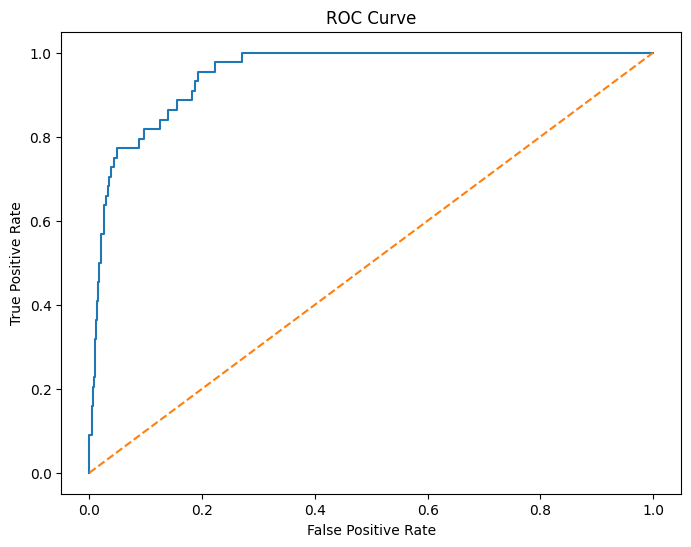

In [41]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    y_test,
    probs_smote
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

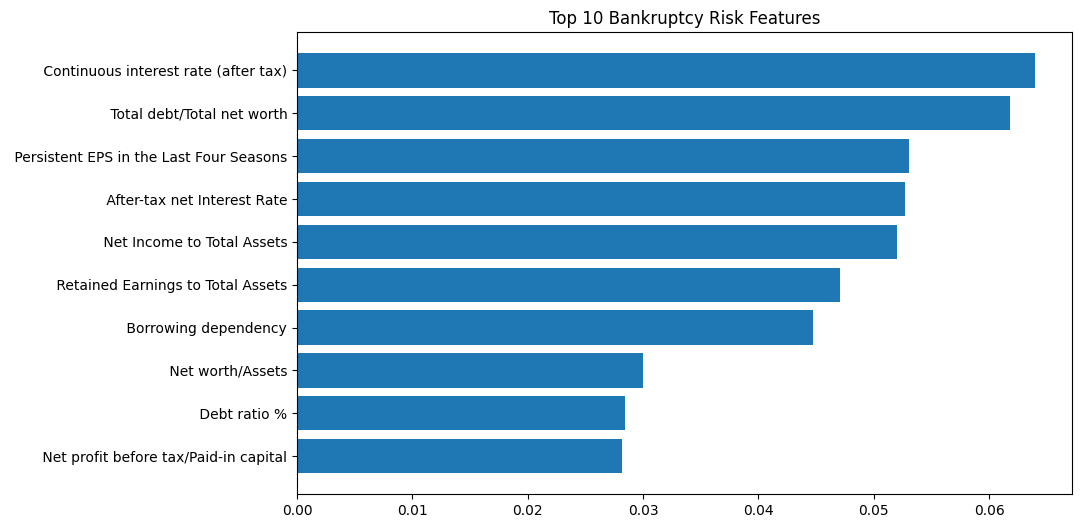

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_smote.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Bankruptcy Risk Features"
)

plt.show()

In [43]:
import joblib

joblib.dump(
    rf_smote,
    "bankruptcy_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [44]:
joblib.dump(
    X_train.columns.tolist(),
    "feature_names.pkl"
)

['feature_names.pkl']

In [45]:
import os

print(os.listdir())

['.config', 'feature_names.pkl', 'bankruptcy_model.pkl', 'data.csv', 'sample_data']


In [46]:
from sklearn.metrics import classification_report

preds_smote = rf_smote.predict(X_test)

print(classification_report(
    y_test,
    preds_smote
))


              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.33      0.77      0.46        44

    accuracy                           0.94      1364
   macro avg       0.66      0.86      0.71      1364
weighted avg       0.97      0.94      0.95      1364

